<a href="https://colab.research.google.com/github/root-epifit/HPC_Sber_2025/blob/main/%D0%94%D0%B74_solution_IP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Домашнее задание 4 - одномерный клеточный автомат

Для реализации одномерного клеточного автомата (https://ru.wikipedia.org/wiki/Правило_110) с периодическими граничными условиями мы воспользуемся распараллеливанием с помощью MPI. Для корректного распараллеливания мы будем использовать так называемые «клетки-призраки» (см. Рисунок ниже).

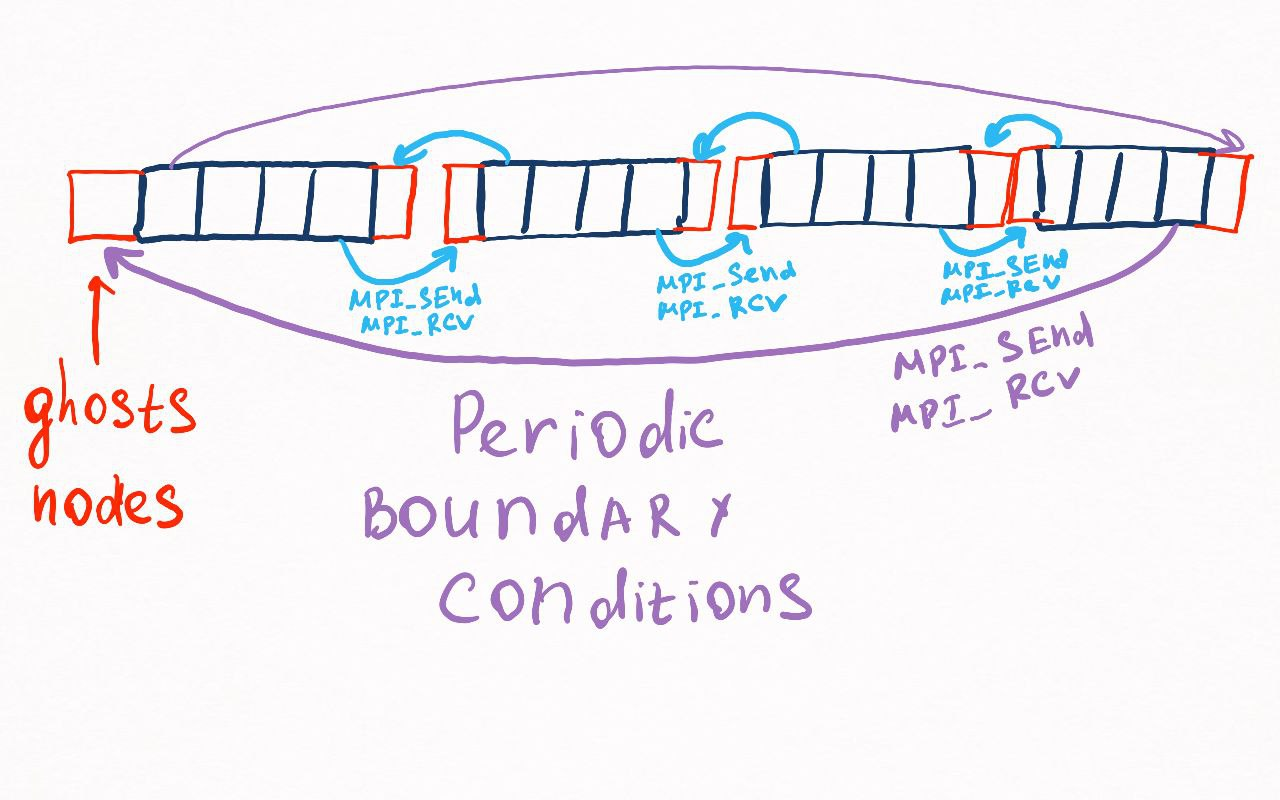

автор кода и рисунка Денис Тауренис (вроде)

Код получит правило в формате числа от 0 до 255. Например, мы хотим использовать правило 130. $130 = 10000010_2$. Это означает, что $000 = 0; 001 = 1; 010 = 0$ ...(все нули)... $111 = 1$. Начальные условия будут выбраны случайным образом.

In [ ]:
%%writefile cellular_periodic.c

#include <mpi.h>
#include <stdio.h>
#include <stdlib.h>
#include <time.h>
#include <string.h>

//Length of the stirng
static const int N = 100;//40000000;

//Number of iterations
static const int Nit = 100;//10;

int main(int argc, char ** argv)
{
    int r = atoi(argv[1]);
    int rule[] = {0, 1, 0, 0, 1, 0, 1, 1};
    int r1 = r;
    for (int i = 7; i>=0; i--){
        rule[i] = r1 / (1 << i);
        r1 -= (r1/(1 << i)) * (1 << i);
    }

    int psize;
    int prank;
    MPI_Status status;

    int ierr;

    ierr = MPI_Init(&argc, &argv);
    ierr = MPI_Comm_rank(MPI_COMM_WORLD, &prank);
    ierr = MPI_Comm_size(MPI_COMM_WORLD, &psize);

    MPI_File_delete(argv[2], MPI_INFO_NULL);

    MPI_Barrier(MPI_COMM_WORLD);
    double t1, t2;
    t1 = MPI_Wtime();

    srand (time(NULL) +  prank);

    MPI_Request request;
    MPI_File fh;
    int rc = MPI_File_open(MPI_COMM_WORLD, argv[2], MPI_MODE_CREATE|MPI_MODE_EXCL|MPI_MODE_WRONLY, MPI_INFO_NULL, &fh);
    int sizeRank = N/psize + ((prank+1)/(N%psize+1) == 0 ? 1 : 0);

    //Size of the chunk corresponded to the thread
    MPI_Offset offset = sizeRank*prank;
    int sizeRow = sizeRank + 2;
    int charSize = sizeRank + (prank==(psize-1));

    char* buf = (char*)malloc(charSize * sizeof(char));
    if (prank == (psize-1))
        buf[charSize-1] = '\n';
    int* row = (int*)malloc(sizeRow * sizeof(int));
    for(int i = 1; i < sizeRow -1; i++)
        row[i] = rand()%2;

    int* rowChanged = (int*)malloc(sizeRow * sizeof(int));


    for (int j = 0; j<Nit; j++){
        if (psize>1)
        {
            //Boundary conditions
            if (prank == 0){
                MPI_Isend(row+1, 1, MPI_INT, psize-1, 1, MPI_COMM_WORLD, &request);
                MPI_Isend(row+sizeRow-2, 1, MPI_INT, 1, 0, MPI_COMM_WORLD, &request);
            } else if (prank == psize - 1){
                MPI_Isend(row+1, 1, MPI_INT, psize-2, 1, MPI_COMM_WORLD, &request);
                MPI_Isend(row+sizeRow-2, 1, MPI_INT, 0, 0, MPI_COMM_WORLD, &request);
            } else{
                MPI_Isend(row+1, 1, MPI_INT, prank-1, 1, MPI_COMM_WORLD, &request);
                MPI_Isend(row+sizeRow-2, 1, MPI_INT, prank + 1, 0, MPI_COMM_WORLD, &request);
            }
            MPI_Recv(row, 1, MPI_INT, MPI_ANY_SOURCE, 0, MPI_COMM_WORLD, &status);
            MPI_Recv(row + sizeRow - 1, 1, MPI_INT, MPI_ANY_SOURCE, 1, MPI_COMM_WORLD, &status);

            ierr =  MPI_Barrier(MPI_COMM_WORLD);
        }
        else{
            row[0] = row[sizeRow-2];
            row[sizeRow-1] = row[1];
        }

        //On step of the iteration with respect to the chink of the thread
        for (int i = 1; i < sizeRow - 1; i++){
            rowChanged[i] = rule[4 * row[i-1] + 2 * row[i] + row[i+1]];
        }
        for (int i = 1; i < sizeRow - 1; i++){
            row[i] = rowChanged[i];
            buf[i-1] = rowChanged[i] +'0';
        }

        //write to file
        MPI_File_write_at(fh, offset, buf, charSize, MPI_CHAR, MPI_STATUS_IGNORE);
        offset+=N+1;

        ierr =  MPI_Barrier(MPI_COMM_WORLD);
    }
    free(row);
    free(buf);
    free(rowChanged);
    MPI_File_close(&fh);
    t2 = MPI_Wtime();
    if (prank == 0)
        printf("MPI_Wtime: %1.4f\n", t2-t1);

    ierr = MPI_Finalize();
    return 0;
}

Overwriting cellular_periodic.c


In [ ]:
!mpicc cellular_periodic.c

Let's see results for rules $120, 140,$ and $30$. These are presented in the images below.

In [ ]:
!mpirun --allow-run-as-root -n 1 ./a.out 30 30.txt

MPI_Wtime: 0.0084


In [ ]:
!mpirun --allow-run-as-root --oversubscribe -n 2 ./a.out 120 120.txt

MPI_Wtime: 0.0201


In [ ]:
!mpirun --allow-run-as-root --oversubscribe -n 4 ./a.out 110 110.txt

MPI_Wtime: 0.0103


In [20]:
def open_data(file):
    filename = open(file, "r")
    data = []
    gr = filename.readline().strip()
    while gr:
        gr = list(map(int,str(gr)))
        data.append(gr)
        gr = filename.readline().strip()
    data = np.array(data)
    return data

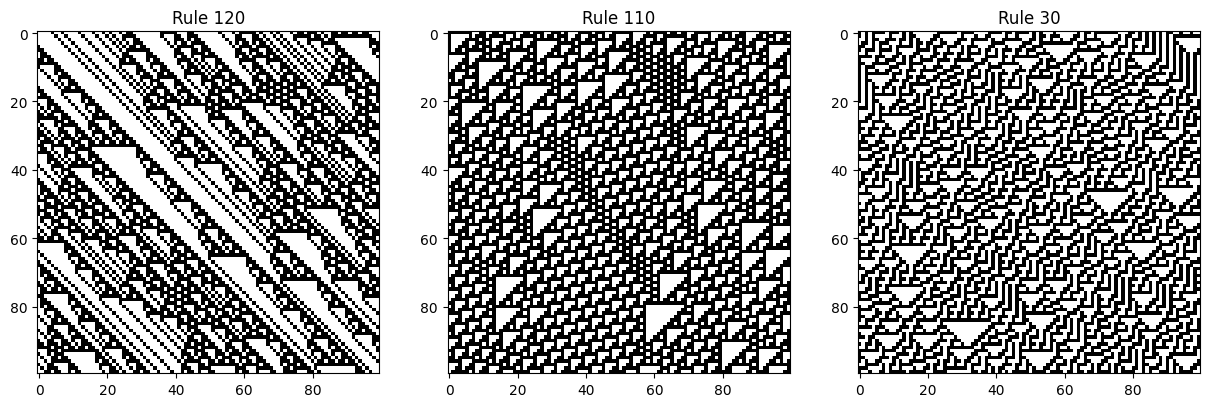

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize = (15, 10))

data = open_data("120.txt")
ax[0].imshow(data, cmap='bone_r')
ax[0].set_title("Rule 120")

data = open_data("110.txt")
ax[1].imshow(data, cmap='bone_r')
ax[1].set_title("Rule 110")

data = open_data("30.txt")
ax[2].set_title("Rule 30")
ax[2].imshow(data, cmap='bone_r')

plt.show()

## Задания

1. Проверить, что код, представленный выше работает на вашем компьютере
2. Измерить время расчета на 1, 2, 4 mpi процессах. Виден ли прирост производительности, при использовании большего числа ядер? Что будет если поварьировать длину массива (параметр **N**)?
3. Попробовать реализовать клеточный автомат на Python. Получится ли сделать код быстрее данной реализации в C? Можно писать код, используя любые инструменты (не только те, что были представлены на занятиях). Можно изпользовать логику, отличную от представленной в сишной реализации.

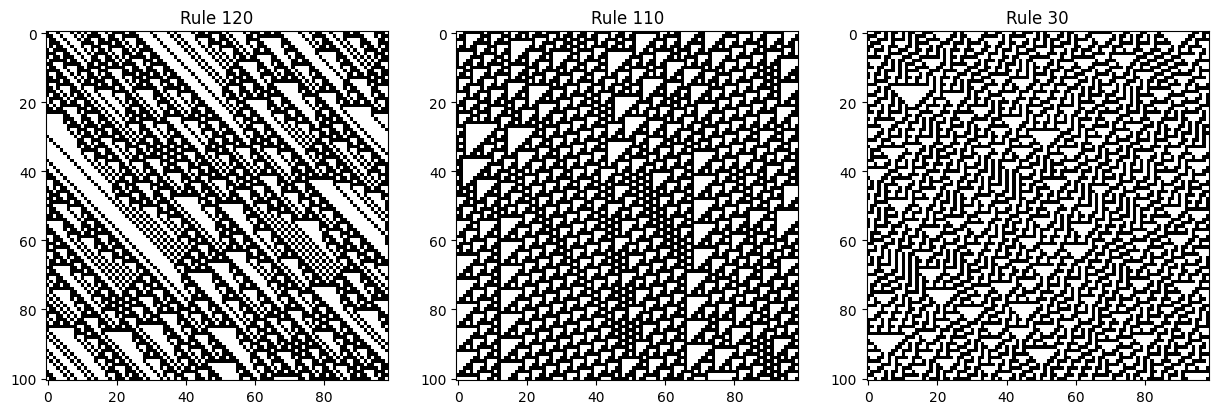

In [56]:
#
# сначала сделаю непараллельный вариант кода
#

import numpy as np

def life(
        rule,           # правило
        N,              # время жизни
        init_state      # начальное состояние
        ):

    output_file = "my"+str(rule)+".txt"

    # шаблоны, с которым будем сравнивать окружение клетки, и соотв.им след.состояния клетки
    patterns = np.array([i for p in "111 110 101 100 011 010 001 000".split() for i in map(int, list(p))]).reshape(8,3)
    states = np.array([i for i in list(map(int, f'{rule:08b}'))])

    # игровое поле
    current_generation  = np.zeros(N+2, dtype=int)       # row[0], row[-1] - клетки-призраки
    left_cell = 1
    right_cell = len(current_generation)-2
    left_ghost_cell = 0
    right_ghost_cell  = len(current_generation)-1

    # заполняем поле начальным состоянием, клетки-признаки оставляем = 0
    current_generation[left_cell:right_cell+1] = init_state[:]

    with open(output_file, "w") as of:

        # Идем по оси времени - от 0 до N включительно.
        for i in range(0, N + 1):

            current_generation[left_ghost_cell] = current_generation[right_cell]
            next_generation  = np.zeros(N + 2, dtype=int)
            #print("before -> ", current_generation)

            for cell in range(left_cell, right_cell+1):

                # Рассылаем клетки-призраки
                if cell == left_cell:  current_generation[left_ghost_cell] = current_generation[right_cell]
                if cell == right_cell: current_generation[right_ghost_cell] = current_generation[left_cell]

                neigbours = current_generation[cell-1:cell+2]

                for p in range(patterns.shape[0]):
                    if np.array_equal(neigbours, patterns[p,:]):
                        next_generation[cell] = states[p]    # новое состояние клетки в соотв.с найденным шаблоном
            #print("after ->  ", next_generation)
            current_generation = next_generation
            s = "".join(([c for c in map(str, current_generation[left_cell:right_cell].tolist())]))+"\n"
            #print(s, end = "")
            of.write(s)

# Запускаем жизни для трех правил
for rule in [30, 110, 120]:
    N=100
    life(rule=rule, N=N, init_state = np.random.randint(0,2,N))

# распечатываем сравниваем с эталонными картинками. Вроде совпали....
fig, ax = plt.subplots(1, 3, figsize = (15, 10))

data = open_data("my120.txt")
ax[0].imshow(data, cmap='bone_r')
ax[0].set_title("Rule 120")

data = open_data("my110.txt")
ax[1].imshow(data, cmap='bone_r')
ax[1].set_title("Rule 110")

data = open_data("my30.txt")
ax[2].set_title("Rule 30")
ax[2].imshow(data, cmap='bone_r')

plt.show()

Картинки совпали.

Но моя модель совсем не такая какая требуется в ДЗ. У меня состояния клеток на линии длиной N меняются поочередно и состояние следующей клетки зависит от нового состояния предыдущей. Ну как бы по линии клеток длиной N пробегает садовник и последовательно меняет содержимое клеток. В каждый кван времени меняется состояние одной клетки.

А надо, чтобы состояния всех клеток на линии длиной N менялись бы разом. Ну как-бы N садовников по команде одновременно меняли бы состояния всех клеток. Т.е. в каждый квант времени одновременно меняются состояния всех клеток.



In [6]:
# устанавливаем mpi4py и проверяем его работу
!pip install mpi4py

In [7]:
from mpi4py import MPI

comm = MPI.COMM_WORLD
my_rank = comm.Get_rank()
mpi_size = comm.Get_size()
print(mpi_size, my_rank)

1 0


In [18]:
# параллельный вариант кода (состояния клеток меняются одноврменно на всей линии)
%%writefile mpi_life.py

from mpi4py import MPI
import numpy as np

comm = MPI.COMM_WORLD
my_rank = comm.Get_rank()
n_processes = comm.Get_size()

rule = 30
N = 10                          # размер игрового поля и продолжительность жизни
output_file = "my_par"+str(rule)+".txt"

# шаблоны, с которым будем сравнивать окружение клетки, и соотв.им след.состояния клетки
patterns = np.array([i for p in "111 110 101 100 011 010 001 000".split() for i in map(int, list(p))]).reshape(8,3)
states = np.array([i for i in list(map(int, f'{rule:08b}'))])

# инициализируем вычислители
p_cells = N//n_processes
start = np.random.randint(0,2,p_cells)
p_current = np.zeros(p_cells+2, dtype=int)
left_cell = 1
right_cell = len(p_current)-2
left_ghost_cell = 0
right_ghost_cell  = len(p_current)-1

# инициализируем первое поколение жизни
p_current[left_cell:right_cell+1] = start[:]  # начальное состояние

# Рассылаем ghost cells
right = my_rank+1
left  = my_rank-1

if my_rank == 0:
    right = my_rank+1 if n_processes > 1 else 0
    left  = n_processes-1

if my_rank == n_processes-1:
    right = 0
    left  = my_rank-1 if n_processes > 1 else 0

comm.send(p_current[right_cell], dest=right, tag=1)
comm.send(p_current[left_cell], dest=left, tag=0)
my_rgc = comm.recv(source=right, tag=0)
my_lgc = comm.recv(source=left, tag=1)

p_current[left_ghost_cell] = my_lgc
p_current[right_ghost_cell] = my_rgc

print(f"{my_rank=}, {start=}, {p_current=}")

# новое поколение
p_next  = np.zeros(p_cells+2, dtype=int)
for cell in range(left_cell, right_cell+1):
    neigbours = p_current[cell-1:cell+2]
    for p in range(patterns.shape[0]):
        if np.array_equal(neigbours, patterns[p,:]):
            p_next[cell] = states[p]    # новое состояние клетки в соотв.с найденным шаблоном
        #print("after ->  ", next_generation)

print(f"{my_rank=}, {p_current=}, {p_next=}")


MPI.Finalize()

Overwriting mpi_life.py


In [13]:
p_current.shape, right_cell, right_ghost_cell, left_cell, left_ghost_cell

((12,), 10, 11, 1, 0)

In [30]:
!mpirun --allow-run-as-root --oversubscribe -n 2 python mpi_life.py

In [11]:
p_buffers.shape

(1, 100)

In [ ]:
#
# сначала сделаю непараллельный вариант кода
#
import numpy as np

rule = 30
N = 100                          # размер игрового поля и продолжительность жизни
start = np.random.randint(0,2,N) # начальное состояние
output_file = "my"+str(rule)+".txt"

# шаблоны, с которым будем сравнивать окружение клетки, и соотв.им след.состояния клетки
patterns = np.array([i for p in "111 110 101 100 011 010 001 000".split() for i in map(int, list(p))]).reshape(8,3)
states = np.array([i for i in list(map(int, f'{rule:08b}'))])

# распечатываем шаблоны и след.состояния клеток
#for i in range(0, patterns.shape[0]):
#    print(patterns[i,:], " --> ", states[i])

# игровое поле
current_generation  = np.zeros(N+2, dtype=int)       # row[0], row[-1] - клетки-призраки
left_cell = 1
right_cell = len(current_generation)-2
left_ghost_cell = 0
right_ghost_cell  = len(current_generation)-1

# заполняем поле начальным состоянием, клетки-признаки оставляем = 0
current_generation[left_cell:right_cell+1] = start[:]

with open(output_file, "w") as of:

    # Идем по оси времени - от 0 до N включительно.
    for i in range(0, N + 1):

        current_generation[left_ghost_cell] = current_generation[right_cell]
        next_generation  = np.zeros(N + 2, dtype=int)
        #print("before -> ", current_generation)

        for cell in range(left_cell, right_cell+1):

            # Рассылаем клетки-призраки
            if cell == left_cell:  current_generation[left_ghost_cell] = current_generation[right_cell]
            if cell == right_cell: current_generation[right_ghost_cell] = current_generation[left_cell]

            neigbours = current_generation[cell-1:cell+2]

            for p in range(patterns.shape[0]):
                if np.array_equal(neigbours, patterns[p,:]):
                    next_generation[cell] = states[p]    # новое состояние клетки в соотв.с найденным шаблоном
        #print("after ->  ", next_generation)
        current_generation = next_generation
        s = "".join(([c for c in map(str, current_generation[left_cell:right_cell].tolist())]))+"\n"
        #print(s, end = "")
        of.write(s)

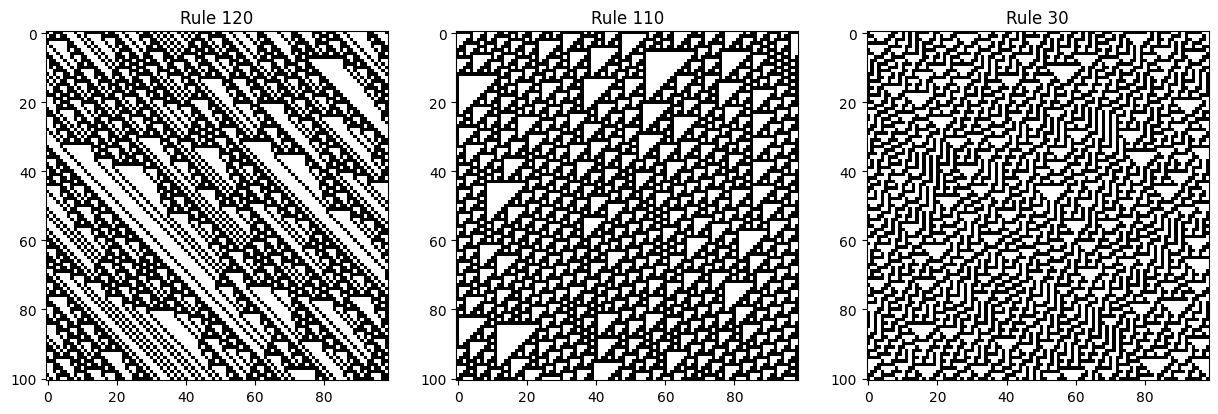

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize = (15, 10))

data = open_data("my120.txt")
ax[0].imshow(data, cmap='bone_r')
ax[0].set_title("Rule 120")

data = open_data("my110.txt")
ax[1].imshow(data, cmap='bone_r')
ax[1].set_title("Rule 110")

data = open_data("my30.txt")
ax[2].set_title("Rule 30")
ax[2].imshow(data, cmap='bone_r')

plt.show()

In [ ]:
"my"+str(N)

'my30'

In [ ]:
with open("Output.txt", "w") as text_file:
    text_file.write("Purchase Amount: %s" % TotalAmount)

'01010101010010111110100000101110'

In [ ]:
new_row

array([0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0])

In [ ]:
row = new_row
row

array([0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0])

In [ ]:
patterns, states
for i in range(0, patterns.shape[0]):
    print(patterns[i,:], " --> ", states[i])


[1 1 1]  -->  0
[1 1 0]  -->  1
[1 0 1]  -->  1
[1 0 0]  -->  0
[0 1 1]  -->  1
[0 1 0]  -->  1
[0 0 1]  -->  1
[0 0 0]  -->  0


In [ ]:
patterns.shape[0]

8

In [ ]:
([1,1,1],1), ([1,1,0], 0), ....)

In [ ]:
patterns = [[1,1,1],[1,1,0],... ]
next_states =  [1,0]

In [ ]:
[i for i in zip("111 110 101 100 011 010 001 000".split(), rule)]

[('111', np.int64(0)),
 ('110', np.int64(1)),
 ('101', np.int64(1)),
 ('100', np.int64(0)),
 ('011', np.int64(1)),
 ('010', np.int64(1)),
 ('001', np.int64(1)),
 ('000', np.int64(0))]

In [ ]:
d = {np.array([1,1,1]):1, np.array([0,1,1]):2}

TypeError: unhashable type: 'numpy.ndarray'

In [ ]:
np.array([i for i in map(int, list("01101110"))]) #    .map(int, i)

array([0, 1, 1, 0, 1, 1, 1, 0])

In [ ]:
print(np.array([i for i in map(int, list("01101110"))]))
print (rule)
print(" ", start)
print(row)

[0 1 1 0 1 1 1 0]
[0 1 1 0 1 1 1 0]
  [0 0 1 1 0 1 0 1 0 1]
[1 0 0 1 1 0 1 0 1 0 1 0]


In [ ]:
# start:stop:step
i = 10
row, row[i-1:i+2]

(array([1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1]), array([0, 1, 1]))

In [ ]:
file = "30.txt"
filename = open(file, "r")
data = []
gr = filename.readline().strip()
print(gr, len(gr))
while gr:
    gr = list(map(int,str(gr)))
    data.append(gr)
    gr = filename.readline().strip()
data = np.array(data)

1010111101110101000000011111101111000011110110111101010001000000101101111111000110101010101100100100 100


In [ ]:
filename = open(file, "r")
gr = filename.readline().strip()
gr

'1010111101110101000000011111101111000011110110111101010001000000101101111111000110101010101100100100'

In [ ]:
np.array(list(map(int,str(gr))))

array([1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0])